In [1]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [48]:
import tensorflow as tf
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *
from sklearn.metrics import confusion_matrix
from mlxtend.plotting import plot_confusion_matrix
import scikitplot
import seaborn as sns
import keras
from keras import models
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D
from keras.optimizers import RMSprop,Adam
from keras.utils import to_categorical
from keras.preprocessing.image import ImageDataGenerator

In [3]:
pip install mlxtend


Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install scikit-plot


Note: you may need to restart the kernel to use updated packages.


In [49]:
# Load the CSV file into a Pandas DataFrame
data = pd.read_csv('C:\\Users\\LapStore\\Downloads\\Tools\\icml_face_data.csv')

In [50]:
# 1. Explore the data
# Getting the shape of the dataset
print(data.shape)

(35887, 3)


In [51]:
# Display basic information about the DataFrame
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35887 entries, 0 to 35886
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   emotion  35887 non-null  int64 
 1    Usage   35887 non-null  object
 2    pixels  35887 non-null  object
dtypes: int64(1), object(2)
memory usage: 841.2+ KB
None


In [52]:
# Display descriptive statistics
print(data.describe())

            emotion
count  35887.000000
mean       3.323265
std        1.873819
min        0.000000
25%        2.000000
50%        3.000000
75%        5.000000
max        6.000000


In [53]:
# Display the first few rows of the DataFrame
print(data.head(5))

   emotion     Usage                                             pixels
0        0  Training  70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...
1        0  Training  151 150 147 155 148 133 111 140 170 174 182 15...
2        2  Training  231 212 156 164 174 138 161 173 182 200 106 38...
3        4  Training  24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...
4        6  Training  4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...


In [54]:
# 2. Handling missing values
# Check for missing values in each column
print(data.isnull().sum())

emotion    0
 Usage     0
 pixels    0
dtype: int64


In [55]:
# 3. Handling duplicate values
# Check for duplicate rows
duplicate_rows = data.duplicated()

# Display the duplicate rows
print("Duplicate Rows except first occurrence:")
print(data[duplicate_rows])

Duplicate Rows except first occurrence:
       emotion        Usage                                             pixels
675          5     Training  255 255 255 255 255 255 255 237 217 146 185 11...
718          2     Training  114 95 82 84 85 120 108 97 83 64 68 85 80 86 1...
1145         5     Training  205 204 205 205 204 203 203 203 202 202 203 20...
1266         3     Training  201 218 246 178 74 62 63 78 85 83 71 65 64 67 ...
1289         5     Training  238 69 24 32 34 33 27 30 41 49 60 64 47 65 80 ...
...        ...          ...                                                ...
35388        5  PrivateTest  229 229 215 150 150 196 158 144 162 134 142 15...
35489        0  PrivateTest  1 30 98 117 115 86 44 43 65 120 128 99 85 82 7...
35607        0  PrivateTest  214 215 213 210 93 35 43 96 118 118 118 119 11...
35610        4  PrivateTest  133 183 181 194 181 179 207 205 211 194 195 21...
35798        5  PrivateTest  14 16 12 16 17 21 23 23 23 22 22 23 23 23 25 2...

[1234 rows 

In [56]:
data[' pixels'][0]

'70 80 82 72 58 58 60 63 54 58 60 48 89 115 121 119 115 110 98 91 84 84 90 99 110 126 143 153 158 171 169 172 169 165 129 110 113 107 95 79 66 62 56 57 61 52 43 41 65 61 58 57 56 69 75 70 65 56 54 105 146 154 151 151 155 155 150 147 147 148 152 158 164 172 177 182 186 189 188 190 188 180 167 116 95 103 97 77 72 62 55 58 54 56 52 44 50 43 54 64 63 71 68 64 52 66 119 156 161 164 163 164 167 168 170 174 175 176 178 179 183 187 190 195 197 198 197 198 195 191 190 145 86 100 90 65 57 60 54 51 41 49 56 47 38 44 63 55 46 52 54 55 83 138 157 158 165 168 172 171 173 176 179 179 180 182 185 187 189 189 192 197 200 199 196 198 200 198 197 177 91 87 96 58 58 59 51 42 37 41 47 45 37 35 36 30 41 47 59 94 141 159 161 161 164 170 171 172 176 178 179 182 183 183 187 189 192 192 194 195 200 200 199 199 200 201 197 193 111 71 108 69 55 61 51 42 43 56 54 44 24 29 31 45 61 72 100 136 150 159 163 162 163 170 172 171 174 177 177 180 187 186 187 189 192 192 194 195 196 197 199 200 201 200 197 201 137 58 98 92

In [57]:
# function to convert pixel values in string format to array format
def stringTOarray_pixel(x):
      return np.array(x.split(' ')).reshape(48, 48, 1).astype('float32')

In [58]:
data[' pixels'] = data[' pixels'].apply(lambda x: stringTOarray_pixel(x))

In [59]:
data.head()

,emotion,Usage,pixels
0,0,Training,"[[[70.0], [80.0], [82.0], [72.0], [58.0], [58...."
1,0,Training,"[[[151.0], [150.0], [147.0], [155.0], [148.0],..."
2,2,Training,"[[[231.0], [212.0], [156.0], [164.0], [174.0],..."
3,4,Training,"[[[24.0], [32.0], [36.0], [30.0], [32.0], [23...."
4,6,Training,"[[[4.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0..."


In [60]:
# Exploring the count of emotion 
data.emotion.value_counts()

emotion
3    8989
6    6198
4    6077
2    5121
0    4953
5    4002
1     547
Name: count, dtype: int64

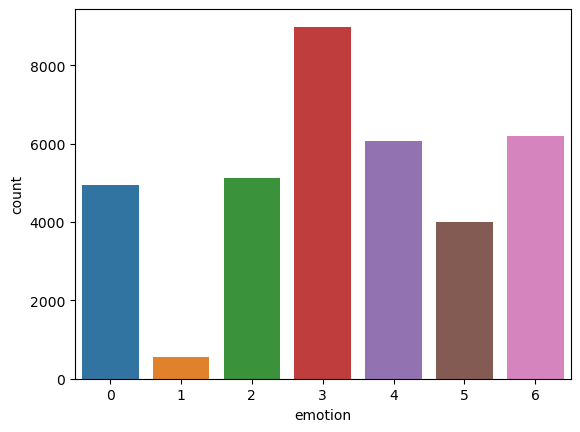

In [61]:
# data emotion column breakdown
sns.countplot(x=data['emotion'])
emotion = ('anger', 'disgust', 'fear', 'happy', 'sad', 'surprise', 'neutral')

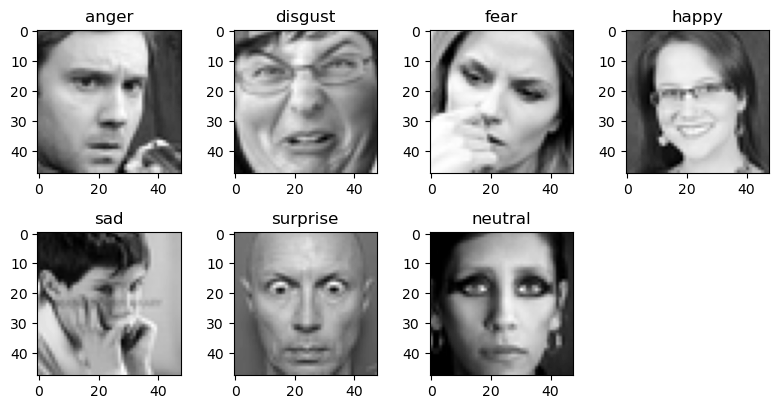

In [62]:
 #Visualize images and plot labels
num_rows = 4
num_cols = 4

fig, axes = plt.subplots(num_rows, num_cols, figsize=(8, 8))
axes = axes.flatten()

emotions = [0, 1, 2, 3, 4, 5, 6]

for i in emotions:
    emotions_data = data[data['emotion'] == i][:1]
    imgage = emotions_data[' pixels'].item()
    imgage = imgage.reshape(48, 48) 
    index = axes[i]
    index.set_title(emotion[i])
    index.imshow(imgage, cmap='gray')

for i in range(len(emotions), num_rows * num_cols):
    fig.delaxes(axes[i])

plt.tight_layout()

plt.show()

In [63]:
# Separate data based on 'Usage' column
training_data = data[data[' Usage'] == 'Training']
test_data = data[data[' Usage'] == 'PublicTest']
validation_data = data[data[' Usage'] == 'PrivateTest']

In [64]:
# Define training, validation and test data
#Training Data
X_training = training_data[' pixels']
Y_training = training_data['emotion']

#Test Data
X_test = test_data[' pixels']
Y_test = test_data['emotion']

#Validation Data
X_validation = validation_data[' pixels']
Y_validation = validation_data['emotion'] 

In [65]:
# Encoding of the target value
X_training = training_data[' pixels']
Y_training = to_categorical(training_data['emotion'])

X_test = test_data[' pixels']
Y_test = to_categorical(test_data['emotion'])

X_validation = validation_data[' pixels']
Y_validation = to_categorical(validation_data['emotion'])

In [66]:
print("Training Shape", np.shape(training_data))
print("Test Shape", np.shape(test_data))
print("Validation Shape", np.shape(validation_data))

Training Shape (28709, 3)
Test Shape (3589, 3)
Validation Shape (3589, 3)


In [67]:
# Reshape and scale the images
X_training = np.stack(X_training, axis = 0)
X_training = X_training.reshape(28709 , 48, 48, 1)

X_test = np.stack(X_test, axis = 0)
X_test = X_test.reshape(3589 , 48, 48, 1)

X_validation = np.stack(X_validation, axis = 0)
X_validation = X_validation.reshape(3589 , 48, 48, 1)

In [68]:
print(X_training.shape, Y_training.shape)
print(X_test.shape, Y_test.shape)
print(X_validation.shape, Y_validation.shape)

(28709, 48, 48, 1) (28709, 7)
(3589, 48, 48, 1) (3589, 7)
(3589, 48, 48, 1) (3589, 7)


In [69]:
# image pre-processing
X_training = X_training/255
X_Test = X_test/255
X_validation = X_validation /255

In [26]:
#CNN MODOEL 
#defining model
#model=Sequential()
model = Sequential([
    #adding convolution layer
    #model.add(Conv2D(32,(3,3),activation=’relu’,input_shape=(28,28,1)))
    Conv2D(32, (3,3), activation = 'relu', padding = 'same', input_shape = (48,48,1)),
    Conv2D(32, (3,3), activation = 'relu', padding = 'same'),
    #adding pooling layer
    #model.add(MaxPool2D(2,2))
    MaxPool2D(2,2),
    Dropout(0.25),
    

    Conv2D(64, (3,3), activation = 'relu', padding = 'same'),
    Conv2D(64, (3,3), activation = 'relu', padding = 'same'),
    MaxPool2D(2,2),
    Dropout(0.25),
    
    
    Conv2D(128, (3,3), activation = 'relu', padding = 'same'),
    Conv2D(128, (3,3), activation = 'relu', padding = 'same'),
    MaxPool2D(2,2),
    Dropout(0.25),
    
    
    #adding fully connected layer
    #model.add(Flatten())
    #model.add(Dense(100,activation=’relu’))
    
    Flatten(),
    
    Dense(64, activation='relu'),
    Dropout(0.25),
    Dense(32, activation='relu'),
    Dropout(0.25),
    
    #adding output layer
    #model.add(Dense(10,activation=’softmax’))
    Dense(7, activation='softmax')
])

model.summary()



Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 48, 48, 32)        320       
                                                                 
 conv2d_1 (Conv2D)           (None, 48, 48, 32)        9248      
                                                                 
 max_pooling2d (MaxPooling2  (None, 24, 24, 32)        0         
 D)                                                              
                                                                 
 dropout (Dropout)           (None, 24, 24, 32)        0         
                                                                 
 conv2d_2 (Conv2D)           (None, 24, 24, 64)        18496     
                                                                 
 conv2d_3 (Conv2D)           (None, 24, 24, 64)        36928     
                                                      

In [27]:
#compiling the model
model.compile(loss='sparse_categorical_crossentropy',optimizer='adam',metrics=['accuracy'])


In [28]:
from keras.utils import to_categorical

# Assuming Y_training is one-hot encoded
Y_training_one_hot = to_categorical(Y_training, num_classes=7)


In [29]:
from keras.utils import to_categorical

# One-hot encode labels
Y_training_one_hot = to_categorical(Y_training, num_classes=7)

# Change the loss function to categorical_crossentropy
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])


In [30]:
#fitting the model
model.fit(X_training,Y_training,epochs=10)

Epoch 1/10


898/898 [==============================] - 74s 80ms/step - loss: 1.8304 - accuracy: 0.2423
Epoch 2/10
898/898 [==============================] - 73s 81ms/step - loss: 1.8164 - accuracy: 0.2500
Epoch 3/10
898/898 [==============================] - 72s 80ms/step - loss: 1.8129 - accuracy: 0.2513
Epoch 4/10
898/898 [==============================] - 72s 81ms/step - loss: 1.8125 - accuracy: 0.2512
Epoch 5/10
898/898 [==============================] - 72s 80ms/step - loss: 1.8115 - accuracy: 0.2513
Epoch 6/10
898/898 [==============================] - 73s 81ms/step - loss: 1.8121 - accuracy: 0.2513
Epoch 7/10
898/898 [==============================] - 71s 79ms/step - loss: 1.8071 - accuracy: 0.2523
Epoch 8/10
898/898 [==============================] - 73s 81ms/step - loss: 1.7794 - accuracy: 0.2677
Epoch 9/10
898/898 [==============================] - 72s 80ms/step - loss: 1.7251 - accuracy: 0.2991
Epoch 10/10
898/898 [==============================] - 72s 80ms/step - loss: 1.6

In [31]:
#evaluting the model
loss,acc = model.evaluate(X_test,Y_test)
print('accuracy of CNN model:', acc)

113/113 [==============================] - 3s 21ms/step - loss: 28.8739 - accuracy: 0.2719
accuracy of CNN model: 0.27194204926490784


In [32]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical
import numpy as np

In [33]:
# Load the CSV file into a Pandas DataFrame
file_path = 'C:\\Users\\LapStore\\Downloads\\Tools\\icml_face_data.csv'
data = pd.read_csv(file_path)


In [34]:

# Data Preprocessing
# Assuming 'pixels' column contains pixel values as a string, you need to convert it to a numpy array
data[' pixels'] = data[' pixels'].apply(lambda x: np.fromstring(x, sep=' '))


In [35]:

# Convert labels to categorical
label_encoder = LabelEncoder()
data['emotion'] = label_encoder.fit_transform(data['emotion'])

# Split the data into training and testing sets
train_data, test_data, train_labels, test_labels = train_test_split(
    data[' pixels'].tolist(), data['emotion'].tolist(), test_size=0.2, random_state=100)

# Convert pixel values to a 2D array
X_train = np.vstack(train_data)
X_test = np.vstack(test_data)

# Convert labels to one-hot encoding
y_train = to_categorical(train_labels, num_classes=7)
y_test = to_categorical(test_labels, num_classes=7)

# Build the Neural Network model
model = Sequential()
model.add(Dense(128, input_shape=(X_train.shape[1],), activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(7, activation='softmax'))

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)

# Evaluate the model on the test set
predictions = model.predict(X_test)
predicted_labels = np.argmax(predictions, axis=1)
accuracy = accuracy_score(test_labels, predicted_labels)
print(f"Test Accuracy: {accuracy}")
# Create a confusion matrix
conf_mat = confusion_matrix(test_labels, predicted_labels)
print("Confusion Matrix:")
print(conf_mat)



Epoch 1/20
718/718 [==============================] - 5s 5ms/step - loss: 12.5203 - accuracy: 0.2105 - val_loss: 6.2341 - val_accuracy: 0.2032
Epoch 2/20
718/718 [==============================] - 3s 4ms/step - loss: 3.2086 - accuracy: 0.2204 - val_loss: 2.3946 - val_accuracy: 0.2506
Epoch 3/20
718/718 [==============================] - 2s 3ms/step - loss: 1.8926 - accuracy: 0.2663 - val_loss: 1.9668 - val_accuracy: 0.2059
Epoch 4/20
718/718 [==============================] - 2s 3ms/step - loss: 1.8130 - accuracy: 0.2837 - val_loss: 1.7410 - val_accuracy: 0.3204
Epoch 5/20
718/718 [==============================] - 2s 3ms/step - loss: 1.8172 - accuracy: 0.2865 - val_loss: 1.8813 - val_accuracy: 0.2941
Epoch 6/20
718/718 [==============================] - 2s 3ms/step - loss: 1.9079 - accuracy: 0.2743 - val_loss: 2.4562 - val_accuracy: 0.2503
Epoch 7/20
718/718 [==============================] - 2s 3ms/step - loss: 1.9797 - accuracy: 0.2311 - val_loss: 1.8157 - val_accuracy: 0.2490
Epoch

In [42]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import numpy as np
import matplotlib.pyplot as plt

In [43]:
# Load the CSV file into a Pandas DataFrame
file_path = 'C:\\Users\\LapStore\\Downloads\\Tools\\icml_face_data.csv'
data = pd.read_csv(file_path)

The provided image represents a PCA (Principal Component Analysis) of emotion data. It is a two-dimensional graphical display that aims to reduce the dimensionality of the original dataset, capturing the most important information in a lower-dimensional space.
By visualizing the emotion data in this lower-dimensional space, we can see the main patterns and correlations in the data. This helps in reducing noise and focusing on the important features, which can then be used for further analysis and processing.

Accuracy: 0.46628587350236833


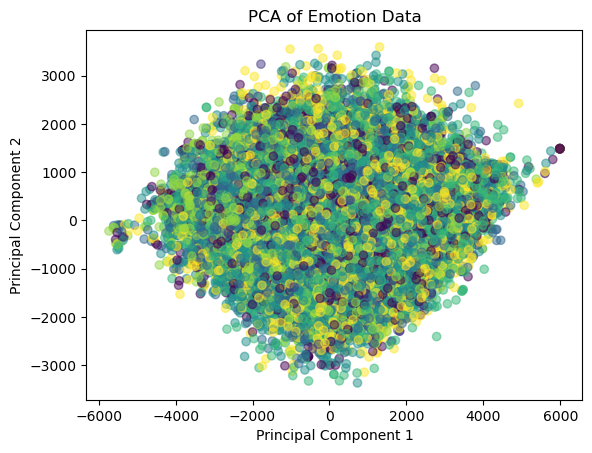

Original shapes: (35887, 2304) (35887, 2304)
Shapes after PCA: (35887, 50)
Number of components: 50


In [44]:
data[' pixels'] = data[' pixels'].apply(lambda x: np.fromstring(x, sep=' '))

# Convert the 'pixels' column to a 2D NumPy array
pixel_values = np.vstack(data[' pixels'].values)
# Flatten the 2D array to create a 1D array for each image
pixels_flat = pixel_values.reshape(pixel_values.shape[0], -1)

# Apply PCA
pca = PCA(n_components=0.98)
pca_result = pca.fit_transform(pixels_flat)

# Apply PCA to reduce dimensionality
num_components = 50  # Choose the number of components
pca = PCA(n_components=num_components)
pca_result = pca.fit_transform(pixel_values)

# Add the PCA components to the DataFrame
for i in range(num_components):
    data[f'pca_{i+1}'] = pca_result[:, i]

# Split the data into features (X) and target labels (y)
X = data.iloc[:, 3:]  # Use PCA components as features, adjust column index accordingly
y = data['emotion']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=100)

# Train a RandomForestClassifier (you can use any other classifier)
model = RandomForestClassifier(n_estimators=500, random_state=100)
model.fit(X_train, y_train)

# Predict on the testing set
y_pred = model.predict(X_test)

# Calculate and print the accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

# Optionally, you can visualize the data in the reduced-dimensional space
# Scatter plot of the first two principal components
plt.scatter(data['pca_1'], data['pca_2'], c=data['emotion'], cmap='viridis', alpha=0.5)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Emotion Data')
plt.show()

# Print shapes and number of components
print("Original shapes:", pixel_values.shape, pixels_flat.shape)
print("Shapes after PCA:", pca_result.shape)
print("Number of components:", pca.n_components_)


In [86]:
import numpy as np
from sklearn.decomposition import PCA

# Assuming 'X_training' and 'X_test' are your 4D arrays representing images
# Print the shapes of the training and test sets before PCA
print("Before PCA - Training Set Shape:", train_images.shape)
print("Before PCA - Test Set Shape:", test_images.shape)

# Reshape each image into a 1D array
xtrain_flat = train_images.reshape(train_images.shape[0], -1)
xtest_flat = test_images.reshape(test_images.shape[0], -1)

# Apply PCA
pca = PCA(n_components=0.98)
pca_train = pca.fit_transform(xtrain_flat)
pca_test = pca.transform(xtest_flat)

# Print the shapes of the transformed training and test sets
print("After PCA - Transformed Training Set Shape:", pca_train.shape)
print("After PCA - Transformed Test Set Shape:", pca_test.shape)

# Print explained variance and cumulative explained variance
print("Explained Variance by Each Principal Component:")
print(pca.explained_variance_)
print("\nExplained Variance Ratio by Each Principal Component:")
print(pca.explained_variance_ratio_)
print("\nCumulative Explained Variance:")
print(np.cumsum(pca.explained_variance_ratio_))



KeyboardInterrupt



In [71]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.utils import class_weight
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical

# Load your data
# Assuming you have a DataFrame 'data' with columns 'emotion', 'Usage', and 'pixels'
# You can load your data here

# Convert labels to categorical
label_encoder = LabelEncoder()
data['emotion'] = label_encoder.fit_transform(data['emotion'])

# Split the data into training and testing sets
train_data, test_data, train_labels, test_labels = train_test_split(
    data[' pixels'].tolist(), data['emotion'].tolist(), test_size=0.2, random_state=100
)

# Convert pixel values to a 3D array
X_train = np.array(train_data)
X_test = np.array(test_data)

# Convert labels to one-hot encoding
y_train = to_categorical(train_labels, num_classes=7)
y_test = to_categorical(test_labels, num_classes=7)

# Reshape data to 4D array (num_samples, height, width, channels)
X_train = X_train.reshape(X_train.shape[0], 48, 48, 1)
X_test = X_test.reshape(X_test.shape[0], 48, 48, 1)

# Build the CNN model
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(48, 48, 1)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Flatten())
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dense(7, activation='softmax'))

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)

# Evaluate the model on the test set
predictions = model.predict(X_test)
predicted_labels = np.argmax(predictions, axis=1)
accuracy = accuracy_score(test_labels, predicted_labels)
print(f"Test Accuracy: {accuracy}")

# Create a confusion matrix
conf_mat = confusion_matrix(test_labels, predicted_labels)
print("Confusion Matrix:")
print(conf_mat)


Epoch 1/20
718/718 [==============================] - 24s 30ms/step - loss: 2.3598 - accuracy: 0.3254 - val_loss: 1.5564 - val_accuracy: 0.3906
Epoch 2/20
718/718 [==============================] - 19s 26ms/step - loss: 1.4547 - accuracy: 0.4450 - val_loss: 1.4989 - val_accuracy: 0.4282
Epoch 3/20
718/718 [==============================] - 18s 26ms/step - loss: 1.2849 - accuracy: 0.5122 - val_loss: 1.4798 - val_accuracy: 0.4410
Epoch 4/20
718/718 [==============================] - 19s 26ms/step - loss: 1.1260 - accuracy: 0.5787 - val_loss: 1.5490 - val_accuracy: 0.4643
Epoch 5/20
718/718 [==============================] - 19s 26ms/step - loss: 0.9330 - accuracy: 0.6561 - val_loss: 1.6616 - val_accuracy: 0.4592
Epoch 6/20
718/718 [==============================] - 20s 28ms/step - loss: 0.7494 - accuracy: 0.7271 - val_loss: 1.7880 - val_accuracy: 0.4533
Epoch 7/20
718/718 [==============================] - 19s 27ms/step - loss: 0.5942 - accuracy: 0.7883 - val_loss: 2.0872 - val_accuracy: